## Idea

This notebook evaluates xgb feature importance using rolling validation, then compresses the feature set accordingly.

---

### Imports

In [1]:
from pathlib import Path

import mlflow
import mlflow.xgboost

import numpy as np
import pandas as pd

import json

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import xgboost as xgb

from sklearn.metrics import average_precision_score, roc_auc_score

### Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v4.parquet"
TEST_PATH = DATA_PATH / "dvc" / "test_v4.parquet"

BEST_PARAMS_PATH = DATA_PATH / "results" / "best_xgb_params.json"

mlflow.set_tracking_uri(f"file:{PROJECT_ROOT/'mlruns'}")
mlflow.set_experiment("simbox_fraud_detection")

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:c:\\Users\\ali.farhat\\Documents\\simbox-project\\mlruns/181740959998191728', creation_time=1781294983928, experiment_id='181740959998191728', last_update_time=1781294983928, lifecycle_stage='active', name='simbox_fraud_detection', tags={}, trace_location=None, workspace='default'>

### Load dataset

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(343365, 42)
(85435, 42)


,msisdn,label,outgoing_calls,incoming_calls,avg_outgoing_duration,avg_incoming_duration,unique_callers,unique_callees,incoming_outgoing_ratio,caller_incoming_ratio,...,afternoon_ratio,evening_calls,evening_ratio,night_calls,night_ratio,deep_night_calls,deep_night_ratio,period_entropy,avg_delay,profile_date
0,22362444330,0,0,5,0.000000,136.200000,4,0,999999.000000,0.800000,...,0.200000,2,0.400000,0,0.000000,0,0.0,1.521928,5413.750000,2022-11-01
1,2250152130667,0,3,0,39.000000,0.000000,0,3,0.000000,0.000000,...,0.000000,3,1.000000,0,0.000000,0,0.0,-0.000000,763.500000,2022-11-01
2,2250152127834,1,9,3,81.777778,421.666667,2,8,0.333333,0.666667,...,0.583333,1,0.083333,0,0.000000,0,0.0,1.280672,2738.090909,2022-11-01
3,2250152127796,0,14,21,69.857143,109.095238,5,8,1.500000,0.238095,...,0.085714,10,0.285714,4,0.114286,0,0.0,2.167014,1584.794118,2022-11-01
4,2250152127414,0,0,1,0.000000,150.000000,1,0,999999.000000,1.000000,...,0.000000,0,0.000000,0,0.000000,0,0.0,-0.000000,0.000000,2022-11-01


### Prepare features

In [4]:
train_df = train_df.set_index(["msisdn", "profile_date"])
test_df = test_df.set_index(["msisdn", "profile_date"])

X_train = train_df.drop(columns="label")
y_train = train_df["label"]

X_test = test_df.drop(columns="label")
y_test = test_df["label"]

print(X_train.shape)

(343365, 39)


---
### Rolling validation feature importance

In [5]:
unique_days = sorted(
    X_train.index.get_level_values("profile_date").unique()
)

validation_days = unique_days[-4:]

with open(BEST_PARAMS_PATH, "r") as f:
    params = json.load(f)

params["objective"] = "binary:logistic"
params["eval_metric"] = "aucpr"
params["seed"] = 42
params["n_jobs"] = -1


feature_importances = []

for val_day in validation_days:

    train_mask = (
        X_train.index.get_level_values("profile_date")
        < val_day
    )

    val_mask = (
        X_train.index.get_level_values("profile_date")
        == val_day
    )

    X_tr = X_train.loc[train_mask]
    y_tr = y_train.loc[train_mask]

    X_val = X_train.loc[val_mask]
    y_val = y_train.loc[val_mask]

    params["scale_pos_weight"] = (
    (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
				)

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=200,
        verbose_eval=False
    )

    preds = model.predict(dval)

    print(
        f"{pd.Timestamp(val_day).date()} | "
        f"PR-AUC = {average_precision_score(y_val, preds):.4f} | "
        f"ROC-AUC = {roc_auc_score(y_val, preds):.4f}"
    )

    feature_importances.append(
        model.get_score(importance_type="gain")
    )

# Average feature importance
importance_df = (
    pd.DataFrame(feature_importances)
    .fillna(0)
    .mean()
    .sort_values(ascending=False)
    .rename("importance")
    .reset_index()
)

importance_df.columns = ["feature", "importance"]

display(importance_df)

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:25:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_boost_round", "params" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2022-11-09 | PR-AUC = 0.4111 | ROC-AUC = 0.8525


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:26:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_boost_round", "params" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2022-11-10 | PR-AUC = 0.4100 | ROC-AUC = 0.8534


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:26:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_boost_round", "params" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2022-11-11 | PR-AUC = 0.4433 | ROC-AUC = 0.8629


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:26:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_boost_round", "params" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2022-11-12 | PR-AUC = 0.4011 | ROC-AUC = 0.8553


,feature,importance
0,flagged_outgoing_ratio,531.806992
1,repeat_call_ratio,375.125420
2,incoming_outgoing_ratio,229.191765
3,incoming_calls,171.639477
4,unique_callees,155.220455
5,avg_outgoing_duration,88.691639
6,flagged_calls,66.418471
7,short_call_ratio,45.169789
8,unique_lac,38.563989
9,night_ratio,37.979245


### Plot feature importance

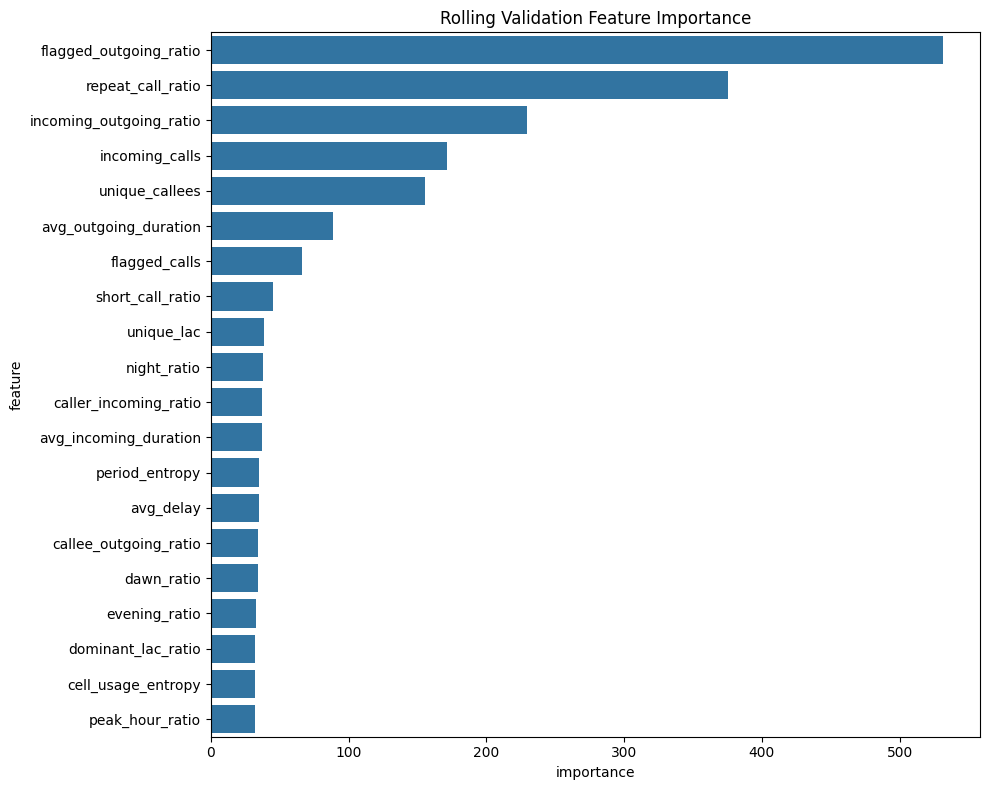

In [6]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title("Rolling Validation Feature Importance")
plt.tight_layout()
plt.show()

---
### Final feature set

In [7]:
FINAL_FEATURES = [
    "repeat_call_ratio",
    "flagged_outgoing_ratio",
    "incoming_outgoing_ratio",
    "incoming_calls",
    "avg_outgoing_duration",
    "flagged_calls",
    "unique_callees",
    "short_call_ratio",
    "avg_incoming_calls_per_hour",
    "avg_outgoing_calls_per_hour",
    "cell_usage_entropy",
    "period_entropy"
]

keep = FINAL_FEATURES + ["label"]

train_df = train_df[keep]
test_df = test_df[keep]

print(train_df.shape)
print(test_df.shape)

(343365, 13)
(85435, 13)


### Overwrite datasets

In [8]:
train_df.reset_index().to_parquet(TRAIN_PATH, index=False)
test_df.reset_index().to_parquet(TEST_PATH, index=False)

print("train_v4 updated.")
print("test_v4 updated.")

train_v4 updated.
test_v4 updated.
